In [9]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
import seaborn as plt_sns
import matplotlib.pyplot as plt

# Set device for PyTorch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Compute Device: {DEVICE}")

# Helper function to plot beautiful confusion matrices
def plot_cm(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    plt_sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

print("\n📥 Loading split data...")
train_data = np.load("/kaggle/input/datasets/alieldinalaa/machine-fault-recognition-split/prepared_data/train_data.npz")
X_train, y_train = train_data['X'], train_data['y']

val_data = np.load("/kaggle/input/datasets/alieldinalaa/machine-fault-recognition-split/prepared_data/val_data.npz")
X_val, y_val = val_data['X'], val_data['y']

test_data = np.load("/kaggle/input/datasets/alieldinalaa/machine-fault-recognition-split/prepared_data/test_data.npz")
X_test, y_test = test_data['X'], test_data['y']

# Merge Train and Val for Cross-Validation & Final Training
X_cv = np.vstack((X_train, X_val))
y_cv = np.concatenate((y_train, y_val))

print(f"✅ Data Ready! CV Shape: {X_cv.shape}, Test Shape: {X_test.shape}")

🚀 Using Compute Device: cuda

📥 Loading split data...
✅ Data Ready! CV Shape: (44303, 256), Test Shape: (11933, 256)


In [10]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 1. Custom Focal Loss for Massive Imbalance ───────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        # CrossEntropyLoss automatically applies LogSoftmax
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction='none')
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss) # Recover the probabilities from the loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()


# ── 2. Enhanced Residual Architecture ────────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(), # Better than ReLU for deep representations
            nn.Dropout(dropout)
        )
        
    def forward(self, x):
        # Skip connection: adds the original input to the output of the block
        return x + self.block(x) 

class EnhancedMLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        
        # 1. Project input up to a wider latent space
        self.in_proj = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU()
        )
        
        # 2. Process through Residual Blocks (Allows deep learning without degradation)
        self.res_blocks = nn.Sequential(
            ResidualBlock(512, dropout=0.3),
            ResidualBlock(512, dropout=0.3)
        )
        
        # 3. Funnel down to the final classes
        self.out_net = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, out_dim)
        )
        
    def forward(self, x):
        x = self.in_proj(x)
        x = self.res_blocks(x)
        return self.out_net(x)


# ── 3. The Scikit-Learn Wrapper ──────────────────────────────────────────────
class TorchMLPWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, n_classes=6, epochs=60, batch_size=256, lr=1e-3):
        self.n_classes  = n_classes
        self.epochs     = epochs
        self.batch_size = batch_size
        self.lr         = lr
        self.scaler     = None
        self.model      = None

    def fit(self, X, y):
        from sklearn.preprocessing import StandardScaler as SkScaler
        
        # Scale data
        self.scaler = SkScaler()
        X_scaled = self.scaler.fit_transform(X)
        
        # Initialize Enhanced Model
        self.model = EnhancedMLP(X_scaled.shape[1], self.n_classes)
        
        if torch.cuda.device_count() > 1:
            self.model = nn.DataParallel(self.model)
        self.model = self.model.to(DEVICE)
        
        Xt = torch.tensor(X_scaled, dtype=torch.float32)
        yt = torch.tensor(y, dtype=torch.long)
        loader = DataLoader(TensorDataset(Xt, yt), batch_size=self.batch_size,
                            shuffle=True, pin_memory=True, num_workers=2)
        
        # Optimizer with slight Weight Decay (L2 Regularization)
        opt = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=1e-3)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.epochs)
        
        # 🚨 USE FOCAL LOSS with Imbalance Weights
        cw = compute_class_weight('balanced', classes=np.unique(y), y=y)
        cw_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
        
        # Gamma=2.0 is the standard sweet spot for Focal Loss
        criterion = FocalLoss(weight=cw_tensor, gamma=2.0)
        
        self.model.train()
        for epoch in range(self.epochs):
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = criterion(self.model(xb), yb)
                loss.backward()
                opt.step()
            scheduler.step()
        return self

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

    def predict_proba(self, X):
        X_scaled = self.scaler.transform(X)
        self.model.eval()
        with torch.no_grad():
            Xt = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
            out = self.model(Xt)
            probs = torch.softmax(out, dim=1).cpu().numpy()
        return probs

    def __deepcopy__(self, memo):
        return TorchMLPWrapper(self.n_classes, self.epochs, self.batch_size, self.lr)

print("✅ Enhanced PyTorch MLP with Residuals & Focal Loss initialized.")

✅ Enhanced PyTorch MLP with Residuals & Focal Loss initialized.


In [11]:
print("🚀 STAGE 1: Tuning XGBoost (GPU Grid Search)...\n" + "="*50)

# 1. Setup XGBoost weights for imbalance
sample_weights_cv = compute_sample_weight(class_weight='balanced', y=y_cv)

# 2. Setup XGBoost Grid Search
param_grid_xgb = {
    'max_depth': [4, 6, 8],             # Depth of the tree (Higher = captures more complex 256D interactions but overfits)
    'learning_rate': [0.05, 0.1, 0.2],  # Step size shrinkage
    'n_estimators': [100, 200, 300],    # Number of trees to build
}

xgb_base = XGBClassifier(
    objective='multi:softprob', # MUST be softprob to output probabilities!
    num_class=6, 
    eval_metric='mlogloss',
    tree_method='hist',         # GPU Acceleration
    device='cuda',              # GPU Acceleration
    random_state=42
)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,               # 3-fold is usually enough for deep embeddings
    scoring='f1_macro', 
    n_jobs=1,           # Keep at 1 to prevent GPU memory crashes
    verbose=1
)

# Fit Grid Search
grid_xgb.fit(X_cv, y_cv, sample_weight=sample_weights_cv)
best_xgb = grid_xgb.best_estimator_
print(f"\n✅ Best XGBoost Params: {grid_xgb.best_params_}")


print("\n🚀 STAGE 2: Training PyTorch MLP...\n" + "="*50)
# We train the MLP directly on the CV data for the specified epochs
# (Grid searching neural networks is often too slow and requires external libraries like Skorch)
mlp_model = TorchMLPWrapper(n_classes=6, epochs=60, batch_size=256, lr=1e-3)
mlp_model.fit(X_cv, y_cv)
print("✅ PyTorch MLP Trained Successfully.")

🚀 STAGE 1: Tuning XGBoost (GPU Grid Search)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

✅ Best XGBoost Params: {'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 300}

🚀 STAGE 2: Training PyTorch MLP...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return F.linear(input, self.weight, self.bias)


✅ PyTorch MLP Trained Successfully.


🤝 STAGE 3: Applying Soft Voting Ensemble...

--- Final Soft Voting Ensemble Metrics ---
              precision    recall  f1-score   support

     M1_Norm       1.00      0.99      1.00      3519
      M1_Abn       0.98      0.99      0.99      1099
     M2_Norm       0.99      1.00      1.00      3508
      M2_Abn       1.00      0.97      0.98       986
     M3_Norm       1.00      1.00      1.00      2785
      M3_Abn       0.90      1.00      0.95        36

    accuracy                           0.99     11933
   macro avg       0.98      0.99      0.98     11933
weighted avg       0.99      0.99      0.99     11933



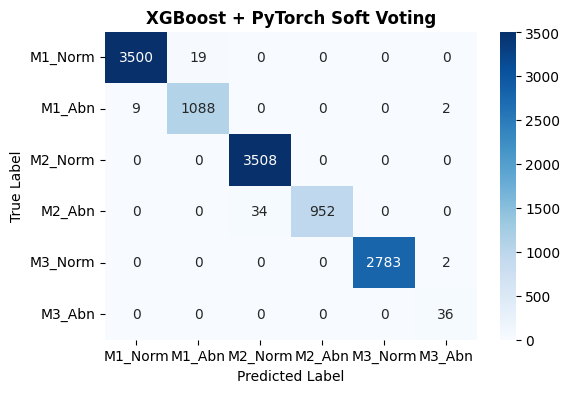


(For comparison, here are the standalone F1 Macro scores):
XGBoost Alone: 0.9850
PyTorch Alone: 0.9819


In [12]:
print("🤝 STAGE 3: Applying Soft Voting Ensemble...\n" + "="*50)

# 1. Extract Probability Matrices shape: (n_samples, 6)
xgb_probs = best_xgb.predict_proba(X_test)
mlp_probs = mlp_model.predict_proba(X_test)

# 2. Soft Voting: Average the probabilities
# You can easily apply weighted soft voting here if you trust one model more!
# e.g., ensemble_probs = (xgb_probs * 0.6) + (mlp_probs * 0.4)
ensemble_probs = (xgb_probs * 0.6) + (mlp_probs * 0.4)
# ensemble_probs = mlp_probs

# 3. Final Prediction: Pick the class with the highest combined probability
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# Metrics
target_names = ["M1_Norm", "M1_Abn", "M2_Norm", "M2_Abn", "M3_Norm", "M3_Abn"]
print("\n--- Final Soft Voting Ensemble Metrics ---")
print(classification_report(y_test, ensemble_preds, target_names=target_names))
plot_cm(y_test, ensemble_preds, "XGBoost + PyTorch Soft Voting", target_names)

# Optional: You can also print the individual model scores to see how much the ensemble improved them!
print("\n(For comparison, here are the standalone F1 Macro scores):")
from sklearn.metrics import f1_score
print(f"XGBoost Alone: {f1_score(y_test, np.argmax(xgb_probs, axis=1), average='macro'):.4f}")
print(f"PyTorch Alone: {f1_score(y_test, np.argmax(mlp_probs, axis=1), average='macro'):.4f}")

## config

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Helper function to plot beautiful confusion matrices
def plot_cm(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# 6 Classes -> 3 Machines (Machine 1=0, Machine 2=1, Machine 3=2)
machine_map = {0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2}
y_train_mach = np.array([machine_map[y] for y in y_train])
y_test_mach = np.array([machine_map[y] for y in y_test])

# 6 Classes -> Binary State (Normal=0, Abnormal=1)
binary_map = {0: 0, 1: 1, 2: 0, 3: 1, 4: 0, 5: 1}
y_train_bin = np.array([binary_map[y] for y in y_train])
y_test_bin = np.array([binary_map[y] for y in y_test])

## svm + 3 xg

🚀 PREPARING DATA FOR CROSS-VALIDATION
Merged CV Data Shape: (44303, 256)

🚀 TRAINING HYBRID TWO-STAGE (SVM + 3x XGBoost)
STAGE 1: Tuning Machine Router (CV=5)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ Best Router Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

--- Stage 1 Metrics (Machine Classification) ---
              precision    recall  f1-score   support

      Mach 1       1.00      1.00      1.00      4618
      Mach 2       1.00      1.00      1.00      4494
      Mach 3       1.00      1.00      1.00      2821

    accuracy                           1.00     11933
   macro avg       1.00      1.00      1.00     11933
weighted avg       1.00      1.00      1.00     11933



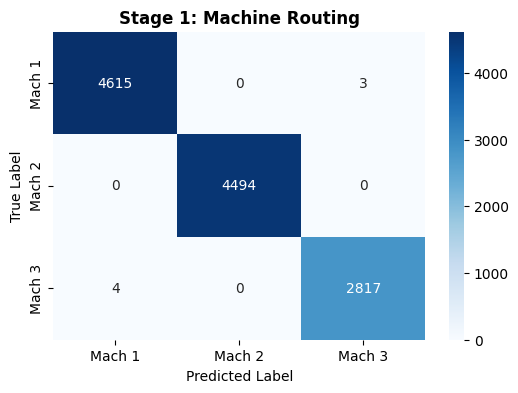


STAGE 2: Tuning Binary XGBoost Classifiers Per Machine...

🔍 Tuning XGBoost for Machine 1...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best Params for Machine 1: {'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 300}

🔍 Tuning XGBoost for Machine 2...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best Params for Machine 2: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}

🔍 Tuning XGBoost for Machine 3...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best Params for Machine 3: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}

🚀 Running Full Hybrid Inference on Test Data...

--- Final Hybrid Two-Stage Metrics (SVM Router + 3x XGBoost) ---
              precision    recall  f1-score   support

     M1_Norm       1.00      1.00      1.00      3519
      M1_Abn       0.99      0.99      0.99      1099
     M2_Norm       0.99      1.00      0.99      3508
      M2_Abn       1.00      0.96      0.98      

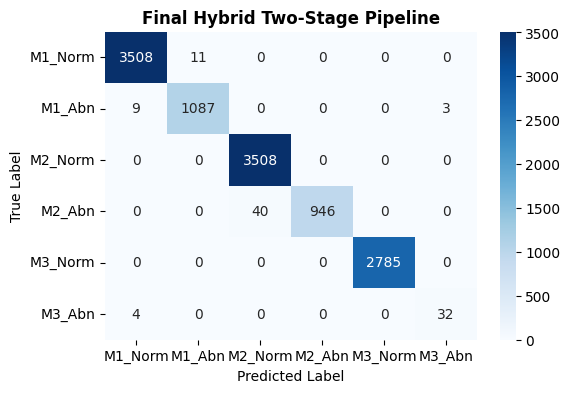

In [14]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Helper function to plot beautiful confusion matrices
def plot_cm(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

print("🚀 PREPARING DATA FOR CROSS-VALIDATION\n" + "="*50)

# 1. Merge Train and Validation sets for Cross-Validation
X_cv = np.vstack((X_train, X_val))
y_cv = np.concatenate((y_train, y_val))

# 2. Re-map the merged labels
machine_map = {0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2}
binary_map  = {0: 0, 1: 1, 2: 0, 3: 1, 4: 0, 5: 1}

y_cv_mach = np.array([machine_map[y] for y in y_cv])
y_cv_bin  = np.array([binary_map[y] for y in y_cv])

y_test_mach = np.array([machine_map[y] for y in y_test])

print(f"Merged CV Data Shape: {X_cv.shape}")

print("\n🚀 TRAINING HYBRID TWO-STAGE (SVM + 3x XGBoost)\n" + "="*50)

# ==========================================
# STAGE 1: Machine Classifier (SVM Router)
# ==========================================
print("STAGE 1: Tuning Machine Router (CV=5)...")
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf'] 
}

grid_router = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1_macro', 
    n_jobs=-1, # Uses all available CPU cores!
    verbose=1
)
grid_router.fit(X_cv, y_cv_mach)

print(f"✅ Best Router Params: {grid_router.best_params_}")

pred_mach_test = grid_router.predict(X_test)
print("\n--- Stage 1 Metrics (Machine Classification) ---")
print(classification_report(y_test_mach, pred_mach_test, target_names=["Mach 1", "Mach 2", "Mach 3"]))
plot_cm(y_test_mach, pred_mach_test, "Stage 1: Machine Routing", ["Mach 1", "Mach 2", "Mach 3"])


# ==========================================
# STAGE 2: Per-Machine Binary XGBoost
# ==========================================
print("\nSTAGE 2: Tuning Binary XGBoost Classifiers Per Machine...")

machine_xgbs = {}

param_grid_xgb = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

for mach_id in range(3):
    print(f"\n🔍 Tuning XGBoost for Machine {mach_id + 1}...")
    
    # 1. Isolate the CV data for this specific machine
    mask = (y_cv_mach == mach_id)
    X_cv_mach = X_cv[mask]
    y_cv_bin_mach = y_cv_bin[mask]
    
    # 2. Compute sample weights for this specific machine's Normal/Abnormal imbalance
    sample_weights_bin = compute_sample_weight(class_weight='balanced', y=y_cv_bin_mach)
    
    xgb_base = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        device='cuda', # GPU acceleration
        random_state=42
    )

    grid_xgb = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid_xgb,
        cv=5,
        scoring='f1_macro',
        n_jobs=1, # Keep 1 to prevent GPU VRAM collisions
        verbose=1
    )

    # 3. Fit Grid Search on just this machine's data
    grid_xgb.fit(X_cv_mach, y_cv_bin_mach, sample_weight=sample_weights_bin)
    
    # 4. Save the winning model to our dictionary
    machine_xgbs[mach_id] = grid_xgb.best_estimator_
    print(f"✅ Best Params for Machine {mach_id + 1}: {grid_xgb.best_params_}")


# ==========================================
# FULL INFERENCE PIPELINE
# ==========================================
print("\n" + "="*50)
print("🚀 Running Full Hybrid Inference on Test Data...")

# 1. Predict all Machines at once using the SVM Router
pred_mach_all = grid_router.predict(X_test)

# 2. Initialize an empty array to hold the state predictions
pred_state_all = np.zeros_like(pred_mach_all)

# 3. Fast Vectorized Inference per Machine
for mach_id in range(3):
    # Find all test samples that were routed to this machine
    idx = np.where(pred_mach_all == mach_id)[0]
    
    if len(idx) > 0:
        # Use that machine's specific XGBoost model to predict Normal/Abnormal
        pred_state_all[idx] = machine_xgbs[mach_id].predict(X_test[idx])

# 4. Reconstruct original 6-class labels mathematically
final_predictions = (pred_mach_all * 2) + pred_state_all

print("\n--- Final Hybrid Two-Stage Metrics (SVM Router + 3x XGBoost) ---")
target_names = ["M1_Norm", "M1_Abn", "M2_Norm", "M2_Abn", "M3_Norm", "M3_Abn"]
print(classification_report(y_test, final_predictions, target_names=target_names))
plot_cm(y_test, final_predictions, "Final Hybrid Two-Stage Pipeline", target_names)

## xg

In [15]:
# import numpy as np
# from xgboost import XGBClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.utils.class_weight import compute_sample_weight
# from sklearn.metrics import classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Helper function for confusion matrix
# def plot_cm(y_true, y_pred, title, labels):
#     cm = confusion_matrix(y_true, y_pred)
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
#     plt.title(title, fontweight='bold')
#     plt.ylabel('True Label')
#     plt.xlabel('Predicted Label')
#     plt.show()

# print("🚀 PREPARING DATA FOR XGBOOST CROSS-VALIDATION\n" + "="*50)

# # 1. Merge Train and Validation sets
# X_cv = np.vstack((X_train, X_val))
# y_cv = np.concatenate((y_train, y_val))

# # 2. Calculate sample weights for the new merged dataset
# # This is critical to ensure XGBoost pays attention to the minority classes
# sample_weights_cv = compute_sample_weight(class_weight='balanced', y=y_cv)

# # 3. Define the Hyperparameter Grid
# # Feel free to adjust these ranges depending on how much time you have
# param_grid = {
#     'max_depth': [4, 6, 8],             # Depth of the tree (Higher = captures more complex 256D interactions but overfits)
#     'learning_rate': [0.05, 0.1, 0.2],  # Step size shrinkage
#     'n_estimators': [100, 200, 300],    # Number of trees to build
# }

# # 4. Initialize the Base XGBoost Classifier
# xgb_base = XGBClassifier(
#     objective='multi:softmax', 
#     num_class=6, 
#     eval_metric='mlogloss',
#     tree_method='hist',   # 🔥 CRITICAL: Enables ultra-fast histogram-based training
#     device='cuda',        # 🔥 CRITICAL: Pushes computation to the GPU! (Use tree_method='gpu_hist' if XGBoost version < 2.0)
#     random_state=42
# )

# # 5. Setup Grid Search
# print("🚀 TRAINING TUNED XGBOOST (GPU ACCELERATED)\n" + "="*50)
# print("Running Grid Search CV (Optimizing for Macro F1)...")

# grid_xgb = GridSearchCV(
#     estimator=xgb_base,
#     param_grid=param_grid,
#     cv=3,
#     scoring='f1_macro', # Force the grid to respect the imbalance
#     n_jobs=1,           # Keep at 1 when using GPU to avoid VRAM collisions
#     verbose=0           # Set to 2 to see the time taken for each fold
# )

# # 6. Fit the Grid Search (Passing the sample weights directly into the fit method!)
# grid_xgb.fit(X_cv, y_cv, sample_weight=sample_weights_cv)

# print(f"\n✅ Best XGBoost Params: {grid_xgb.best_params_}")

# # 7. Final Inference and Metrics
# print("\nRunning Inference on Test Data...")
# xgb_best_model = grid_xgb.best_estimator_
# xgb_preds = xgb_best_model.predict(X_test)

# target_names = ["M1_Norm", "M1_Abn", "M2_Norm", "M2_Abn", "M3_Norm", "M3_Abn"]

# print("\n--- Final Tuned XGBoost Metrics ---")
# print(classification_report(y_test, xgb_preds, target_names=target_names))
# plot_cm(y_test, xgb_preds, "Tuned XGBoost Classification", target_names)

In [17]:
import joblib
import os
import shutil
import numpy as np
from IPython.display import FileLink, display

print("💾 SAVING MODELS AND DATA TO DISK...\n" + "="*50)

# ---------------------------------------------------------
# 1. Save Global XGBoost Model
# ---------------------------------------------------------
# Assumes the variable is named 'best_xgb'
joblib.dump(best_xgb, 'global_xgboost.pkl')
print("✅ Saved: global_xgboost.pkl")

# ---------------------------------------------------------
# 2. Save Hybrid Model (SVM Router + 3x Machine XGBoosts)
# ---------------------------------------------------------
# We bundle the router and the dictionary of 3 models into one .pkl file
hybrid_dict = {
    'router': grid_router.best_estimator_, # The tuned SVM
    'machine_xgbs': machine_xgbs           # The dictionary of 3 XGBoost models
}
joblib.dump(hybrid_dict, 'hybrid_svm_3xgb.pkl')
print("✅ Saved: hybrid_svm_3xgb.pkl")

# ---------------------------------------------------------
# 3. Save Soft Voting Models (XGBoost + PyTorch MLP)
# ---------------------------------------------------------
softvote_dict = {
    'xgb': best_xgb,
    'mlp': mlp_model
}
joblib.dump(softvote_dict, 'softvote_models.pkl')
print("✅ Saved: softvote_models.pkl (Note: Requires class definitions to load later!)")

# ---------------------------------------------------------
# 4. Prepare Test Data
# ---------------------------------------------------------
test_path = "test_data.npz"

# Safest way to ensure test data is perfectly synced with your current session:
# Re-save it directly from the variables currently in memory
np.savez_compressed(test_path, X=X_test, y=y_test)
print("✅ Saved: test_data.npz")


# =========================================================
# 🔗 GENERATE DOWNLOAD LINKS
# =========================================================
print("\n" + "="*50)
print("📥 DOWNLOAD LINKS READY (Click to download directly)")
print("="*50)

display(FileLink('global_xgboost.pkl'))
display(FileLink('hybrid_svm_3xgb.pkl'))
display(FileLink('softvote_models.pkl'))
display(FileLink('test_data.npz'))

💾 SAVING MODELS AND DATA TO DISK...
✅ Saved: global_xgboost.pkl
✅ Saved: hybrid_svm_3xgb.pkl
✅ Saved: softvote_models.pkl (Note: Requires class definitions to load later!)
✅ Saved: test_data.npz

📥 DOWNLOAD LINKS READY (Click to download directly)


/kaggle/working/global_xgboost.pkl

/kaggle/working/hybrid_svm_3xgb.pkl

/kaggle/working/softvote_models.pkl

/kaggle/working/test_data.npz